<a href="https://colab.research.google.com/github/davidebtt/chemical_pycode/blob/quantum-theory/wave%20packets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📡 Photon as a Wave Packet

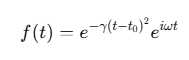

This form describes a **Gaussian-modulated oscillation**, which localizes the photon in time while still carrying a specific central frequency — very useful in quantum optics, communication, and wave mechanics.


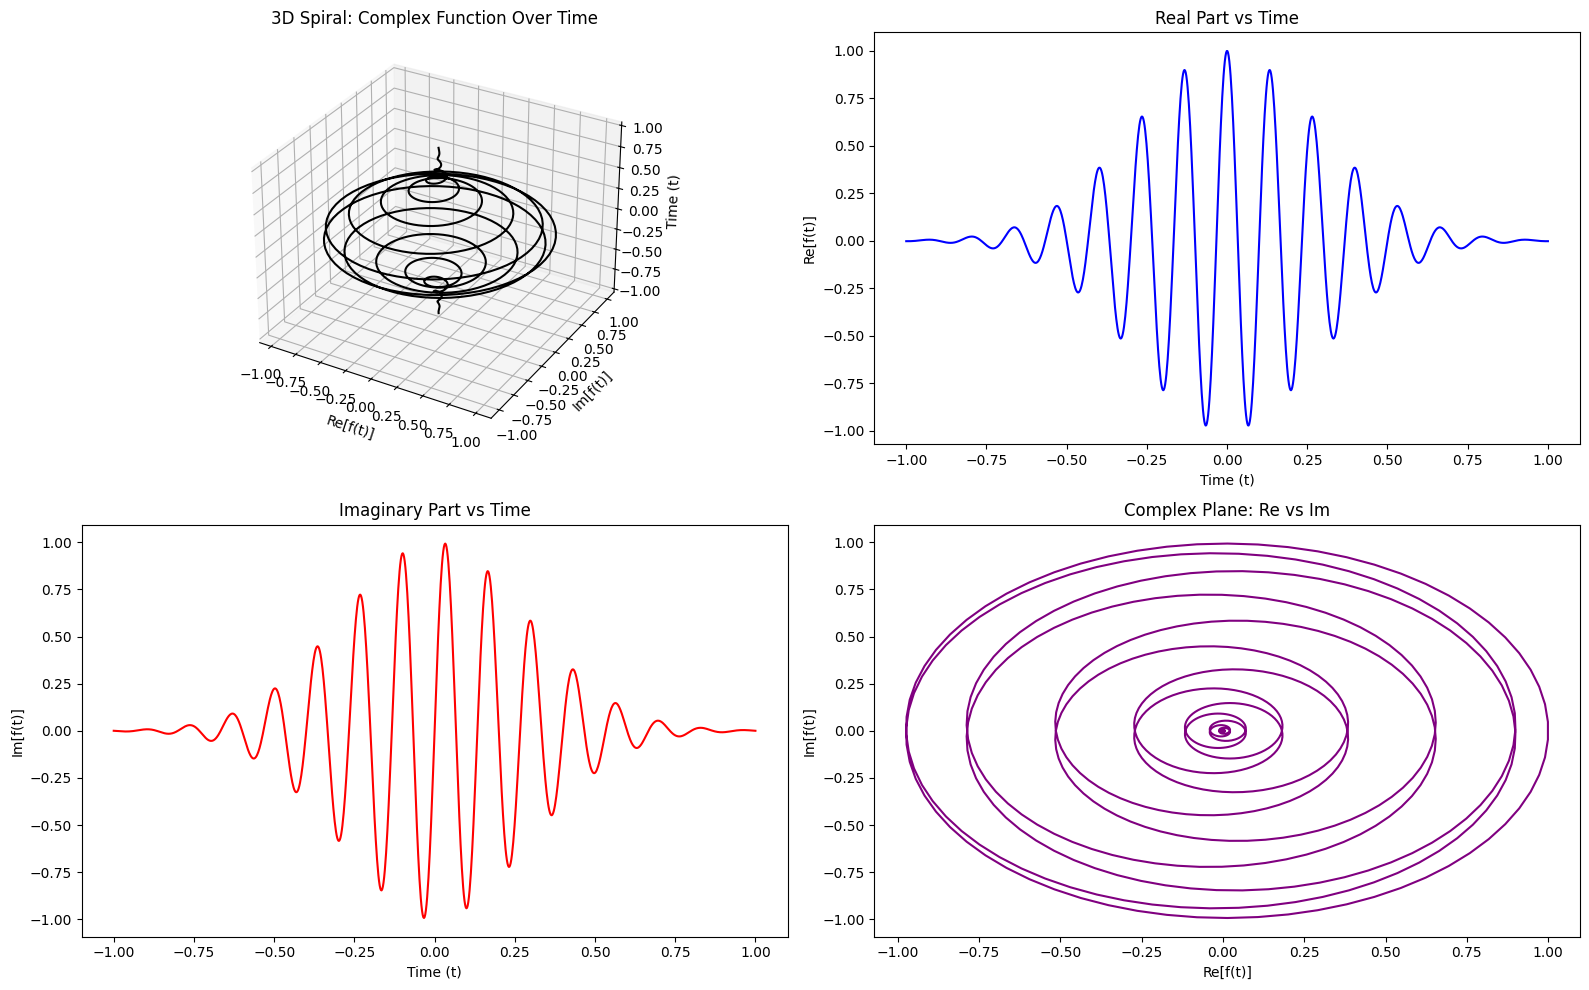

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
gamma = 6                  # Controls how fast the amplitude decays
omega = 15 * np.pi          # Frequency of oscillation
t0 = 0                      # Center of the Gaussian
t = np.linspace(-1, 1, 1000)

# Gaussian envelope and complex function components
envelope = np.exp(-gamma * (t - t0)**2)
real_part = envelope * np.cos(omega * t)
imag_part = envelope * np.sin(omega * t)

# Create figure with subplots
fig = plt.figure(figsize=(16, 10))

# 3D plot: Re vs Im vs t
ax1 = fig.add_subplot(221, projection='3d')
ax1.plot(real_part, imag_part, t, color='black')
ax1.set_xlabel('Re[f(t)]')
ax1.set_ylabel('Im[f(t)]')
ax1.set_zlabel('Time (t)')
ax1.set_title('3D Spiral: Complex Function Over Time')

# 2D: Re[f(t)] vs t
ax2 = fig.add_subplot(222)
ax2.plot(t, real_part, color='blue')
ax2.set_xlabel('Time (t)')
ax2.set_ylabel('Re[f(t)]')
ax2.set_title('Real Part vs Time')

# 2D: Im[f(t)] vs t
ax3 = fig.add_subplot(223)
ax3.plot(t, imag_part, color='red')
ax3.set_xlabel('Time (t)')
ax3.set_ylabel('Im[f(t)]')
ax3.set_title('Imaginary Part vs Time')

# 2D: Re vs Im (Complex Plane Projection)
ax4 = fig.add_subplot(224)
ax4.plot(real_part, imag_part, color='purple')
ax4.set_xlabel('Re[f(t)]')
ax4.set_ylabel('Im[f(t)]')
ax4.set_title('Complex Plane: Re vs Im')

plt.tight_layout()
plt.show()



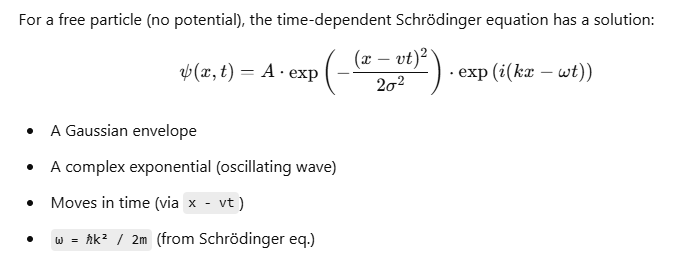

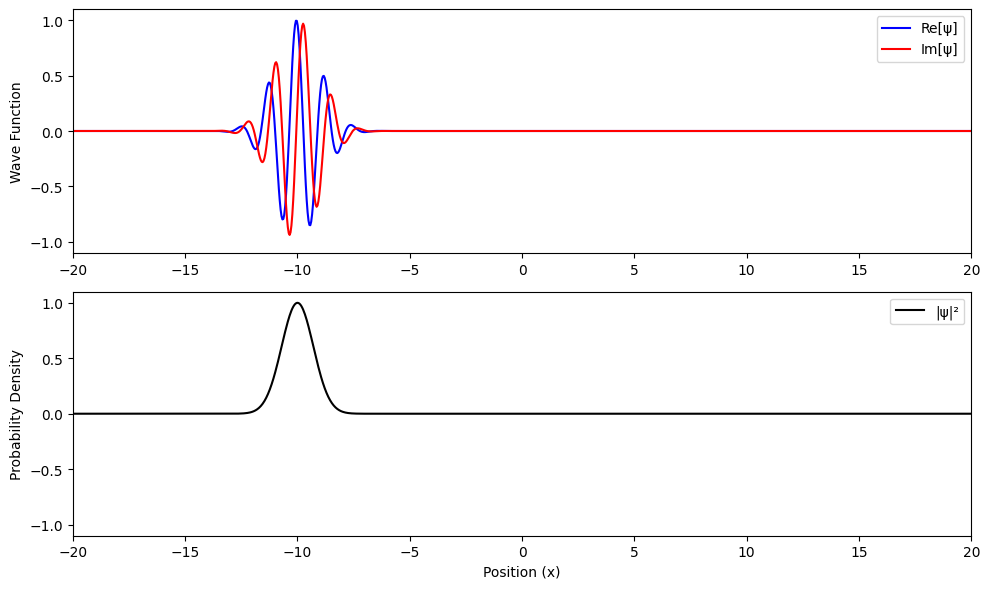

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Constants
hbar = 1.0    # Reduced Planck constant
m = 1.0       # Particle mass

# Wave packet parameters
k0 = 5.0             # Central wave number
sigma = 1.0          # Width of the Gaussian
x0 = -10.0           # Initial position
N = 1000             # Number of spatial points
x = np.linspace(-20, 20, N)
dx = x[1] - x[0]
t_max = 2.0
frames = 200
dt = t_max / frames

# Dispersion relation for free particle
omega_k = lambda k: (hbar * k**2) / (2 * m)
omega0 = omega_k(k0)

# Precompute envelope
def psi_xt(x, t):
    envelope = np.exp(-(x - x0 - (hbar * k0 / m) * t)**2 / (2 * sigma**2))
    phase = np.exp(1j * (k0 * x - omega0 * t))
    return envelope * phase

# Set up figure
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
line1, = ax[0].plot([], [], label='Re[ψ]', color='blue')
line2, = ax[0].plot([], [], label='Im[ψ]', color='red')
line3, = ax[1].plot([], [], label='|ψ|²', color='black')

for a in ax:
    a.set_xlim(x[0], x[-1])
    a.set_ylim(-1.1, 1.1)
    a.legend()

ax[0].set_ylabel('Wave Function')
ax[1].set_ylabel('Probability Density')
ax[1].set_xlabel('Position (x)')

# Animation function
def animate(i):
    t = i * dt
    psi = psi_xt(x, t)
    line1.set_data(x, np.real(psi))
    line2.set_data(x, np.imag(psi))
    line3.set_data(x, np.abs(psi)**2)
    return line1, line2, line3

ani = animation.FuncAnimation(fig, animate, frames=frames, interval=50, blit=True)
plt.tight_layout()
plt.show()
